<a href="https://colab.research.google.com/github/mmouree/Machine-Learning/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install Kaggle API
!pip install -q kaggle

# Upload kaggle.json file (from Kaggle account settings)
from google.colab import files
files.upload()

# Move kaggle.json to correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
# Download dataset
!kaggle datasets download -d nikhileswarkomati/suicide-watch

# Unzip dataset
!unzip -q suicide-watch.zip

# Check files
import os
print(os.listdir())

Dataset URL: https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch
License(s): CC-BY-SA-4.0
suicide-watch.zip: Skipping, found more recently modified local copy (use --force to force download)
['.config', 'Suicide_Detection.csv', 'suicide-watch.zip', 'sample_data']


In [ ]:
# 1. Import libraries

import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC



In [ ]:
# Load dataset

import os

csv_files = [f for f in os.listdir() if f.endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found after unzip.")

file_path = csv_files[0]
print("Using file:", file_path)

df = pd.read_csv(file_path)
print("Shape:", df.shape)
df.head()


# Standardize columns

df.columns = [c.strip().lower() for c in df.columns]

# Drop unnecessary columns
for col in ["unnamed: 0", "index", "id"]:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Detect columns
text_col = None
label_col = None

for col in df.columns:
    if "text" in col:
        text_col = col
    if "class" in col or "label" in col:
        label_col = col

df = df[[text_col, label_col]].copy()
df.columns = ["text", "label"]



Using file: Suicide_Detection.csv
Shape: (232074, 3)


In [ ]:

# Cleaning

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)




Class distribution:
label
suicide        116037
non-suicide    116037
Name: count, dtype: int64


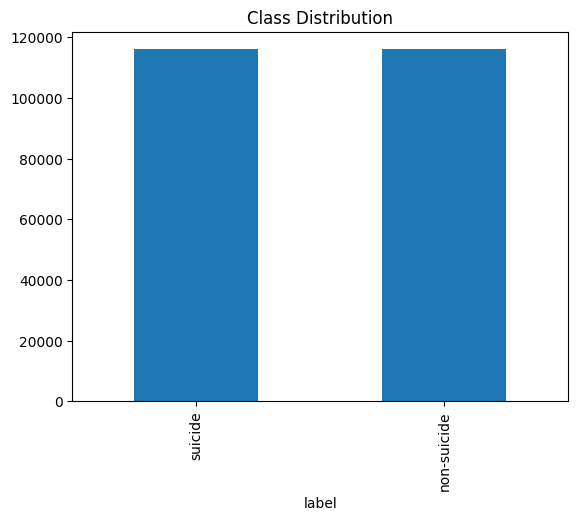

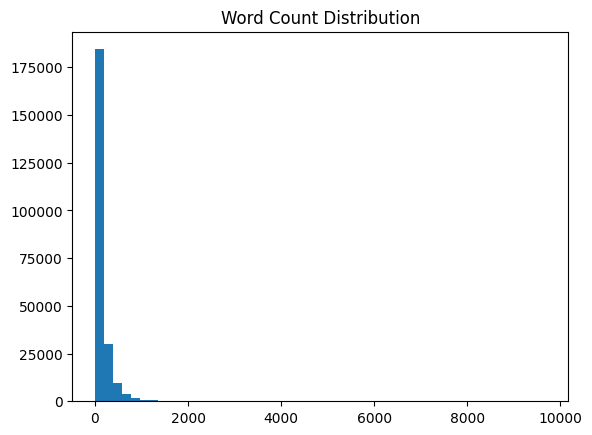


Top words for suicide:
[('t', 372027), ('m', 263763), ('just', 204422), ('s', 161889), ('don', 159969), ('like', 131639), ('want', 128367), ('life', 113059), ('feel', 108128), ('know', 106740), ('ve', 105701), ('people', 73097), ('time', 70869), ('really', 65174), ('think', 57522), ('going', 57409), ('friends', 48646), ('help', 46816), ('years', 46412), ('anymore', 42264)]

Top words for non-suicide:
[('t', 71414), ('s', 59664), ('filler', 54604), ('m', 54135), ('just', 53663), ('like', 50560), ('don', 29251), ('know', 24917), ('people', 22142), ('fuck', 21528), ('want', 20517), ('day', 18806), ('really', 18427), ('time', 16724), ('feel', 14572), ('got', 14572), ('ve', 14504), ('think', 14415), ('school', 14276), ('good', 12909)]


In [ ]:

# Basic EDA

print("\nClass distribution:")
print(df["label"].value_counts())

# Plot class distribution
df["label"].value_counts().plot(kind="bar", title="Class Distribution")
plt.show()

# Word count
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.hist(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()


# Top words

stop_words = set(ENGLISH_STOP_WORDS)

def get_top_words(text_series):
    words = []
    for text in text_series:
        words.extend([w for w in text.split() if w not in stop_words])
    return Counter(words).most_common(20)

for label in df["label"].unique():
    print(f"\nTop words for {label}:")
    print(get_top_words(df[df["label"] == label]["clean_text"]))



In [ ]:
# Printing the first 5 rows

df.head()


,text,label,clean_text,word_count
0,Ex Wife Threatening SuicideRecently I left my ...,suicide,ex wife threatening suiciderecently i left my ...,146
1,Am I weird I don't get affected by compliments...,non-suicide,am i weird i don t get affected by compliments...,29
2,Finally 2020 is almost over... So I can never ...,non-suicide,finally is almost over so i can never hear has...,25
3,i need helpjust help me im crying so hard,suicide,i need helpjust help me im crying so hard,9
4,"I’m so lostHello, my name is Adam (16) and I’v...",suicide,i m so losthello my name is adam and i ve been...,452


In [ ]:

# Label encoding

label_map = {label: i for i, label in enumerate(df["label"].unique())}
df["label_encoded"] = df["label"].map(label_map)

X = df["clean_text"]
y = df["label_encoded"]



In [ ]:

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [ ]:
# Define three simple ML models

models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("model", MultinomialNB())
    ]),

    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000)),
        ("model", LinearSVC())
    ])
}


Model: Logistic Regression
Accuracy: 0.9357
F1 Score: 0.9357

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     23208
           1       0.93      0.94      0.94     23207

    accuracy                           0.94     46415
   macro avg       0.94      0.94      0.94     46415
weighted avg       0.94      0.94      0.94     46415



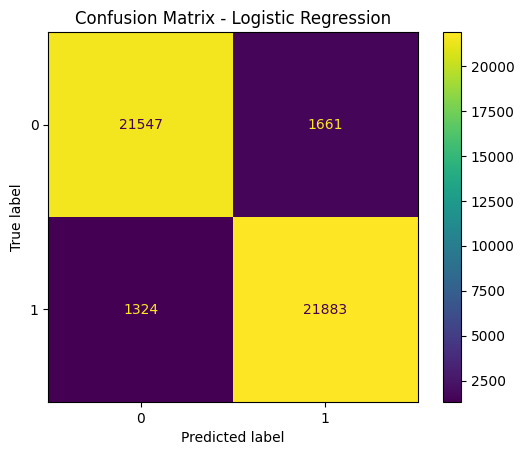


Model: Naive Bayes
Accuracy: 0.9034
F1 Score: 0.9033

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     23208
           1       0.94      0.86      0.90     23207

    accuracy                           0.90     46415
   macro avg       0.91      0.90      0.90     46415
weighted avg       0.91      0.90      0.90     46415



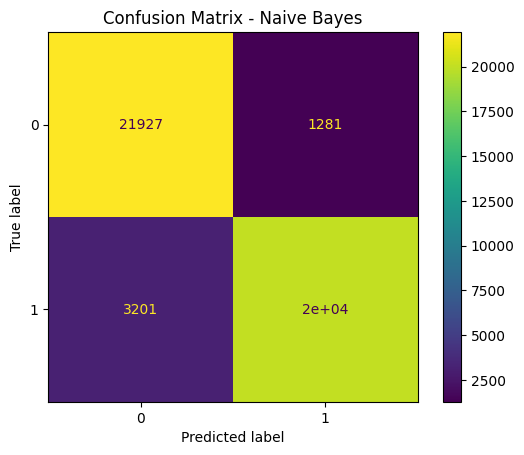


Model: Linear SVM
Accuracy: 0.9368
F1 Score: 0.9368

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     23208
           1       0.93      0.94      0.94     23207

    accuracy                           0.94     46415
   macro avg       0.94      0.94      0.94     46415
weighted avg       0.94      0.94      0.94     46415



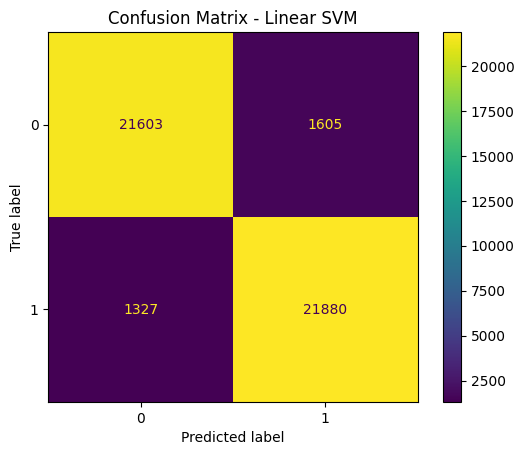

In [ ]:
# Train and evaluate the models

results = []

for name, model in models.items():
    print("\n" + "="*50)
    print("Model:", name)
    print("="*50)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(accuracy, 4))
    print("F1 Score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1 Score": f1
    })

In [ ]:
# Compare model performance

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("Model Comparison:")
display(results_df)

Model Comparison:


,Model,Accuracy,F1 Score
2,Linear SVM,0.936831,0.936829
0,Logistic Regression,0.935689,0.935686
1,Naive Bayes,0.903436,0.903271


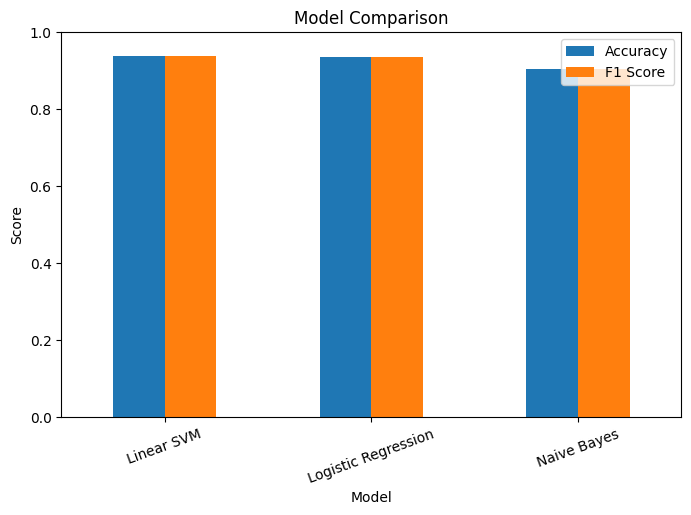

In [ ]:
# Plot model comparison

results_df.plot(
    x="Model",
    y=["Accuracy", "F1 Score"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [ ]:
# Identify the best model

best_model = results_df.iloc[0]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", round(best_model["Accuracy"], 4))
print("Best F1 Score:", round(best_model["F1 Score"], 4))

Best Model: Linear SVM
Best Accuracy: 0.9368
Best F1 Score: 0.9368


This project used the Suicide and Depression Detection dataset from Kaggle.
The goal was to classify social media posts as suicide-related or non-suicide-related.
The text data was cleaned by removing URLs, special characters, and extra spaces.
TF-IDF was used to convert text into numerical features.
Three models were compared: Logistic Regression, Naive Bayes, and Linear SVM.
The best-performing model was Linear SVM based on F1 score.
F1 score was used because it balances precision and recall, which is important for sensitive text classification tasks.
